# AgroESG Analytics
## 01 — Exploração dos Dados IBGE/PAM

**Fonte:** IBGE — Pesquisa Agrícola Municipal (PAM)  
**Tabela SIDRA:** 1612  
**Culturas:** Soja (em grão) e Cana-de-açúcar  
**Período bruto disponível:** 2018–2024  
**Granularidade:** Município

### Objetivos

- compreender a estrutura original da base;
- selecionar as variáveis relevantes;
- verificar valores ausentes e inconsistências;
- validar tipos e unidades;
- padronizar código IBGE, município, UF e região;
- calcular indicadores derivados de produção;
- preparar a base para integração com clima, solo, emissões e queimadas.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

In [3]:
# Raiz do projeto
PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "ibge_pam"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "ibge_pam"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Projeto:", PROJECT_ROOT)
print("Entrada:", RAW_DIR)
print("Saída:", PROCESSED_DIR)

Projeto: C:\Users\Elaine Cristina\Downloads\agroesg-analytics
Entrada: C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\raw\ibge_pam
Saída: C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\processed\ibge_pam


In [4]:
arquivos = list(RAW_DIR.glob("*"))

for arquivo in arquivos:
    tamanho_mb = arquivo.stat().st_size / (1024 ** 2)
    print(f"{arquivo.name} -> {tamanho_mb:.2f} MB")

pam_1612_soja_cana_municipios_2018_2024.csv -> 2.87 MB


In [5]:
arquivo_pam = RAW_DIR / "pam_1612_soja_cana_municipios_2018_2024.csv"

with open(arquivo_pam, "r", encoding="utf-8-sig") as arquivo:
    for _ in range(5):
        print(arquivo.readline())

"Tabela 1612 - Área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção das lavouras temporárias"

"Variável - Área plantada (Hectares)"

"Cód.";"Município";"Ano x Produto das lavouras temporárias"

"Cód.";"Município";"2018";;"2019";;"2020";;"2021";;"2022";;"2023";;"2024"

"Cód.";"Município";"Cana-de-açúcar";"Soja (em grão)";"Cana-de-açúcar";"Soja (em grão)";"Cana-de-açúcar";"Soja (em grão)";"Cana-de-açúcar";"Soja (em grão)";"Cana-de-açúcar";"Soja (em grão)";"Cana-de-açúcar";"Soja (em grão)";"Cana-de-açúcar";"Soja (em grão)"



In [10]:
import pandas as pd

# Anos disponíveis na base
anos = range(2018, 2025)

# Construção dos nomes das colunas
colunas = [
    "codigo_ibge",
    "municipio"
]

for ano in anos:
    colunas.extend([
        f"cana_{ano}",
        f"soja_{ano}"
    ])

# Leitura da base PAM
df = pd.read_csv(
    arquivo_pam,
    sep=";",
    encoding="utf-8-sig",
    decimal=",",
    skiprows=5,
    header=None,
    names=colunas,
    na_values=["-"],
    dtype={"codigo_ibge": "string"},
    low_memory=False
)

df.head()

,codigo_ibge,municipio,cana_2018,soja_2018,cana_2019,soja_2019,cana_2020,soja_2020,cana_2021,soja_2021,cana_2022,soja_2022,cana_2023,soja_2023,cana_2024,soja_2024
0,1100015,Alta Floresta D'Oeste (RO),NaN,450,NaN,450,10,450,10,1072,NaN,1117,5,1318,5,1697
1,1100023,Ariquemes (RO),20,5600,20,7893,20,7782,20,6979,20,9191,25,13106,25,15980
2,1100031,Cabixi (RO),250,24780,250,24630,70,24950,80,27705,10,30000,6,30781,6,32000
3,1100049,Cacoal (RO),20,570,20,1000,21,1000,23,2160,21,2605,26,4561,26,6411
4,1100056,Cerejeiras (RO),115,32600,100,35190,100,36150,10,36430,10,35216,13,35121,20,40000


In [11]:
print("Dimensão da base:", df.shape)

print("\nColunas:")
print(df.columns.tolist())

print("\nTipos:")
print(df.dtypes)

df.head()

Dimensão da base: (27862, 16)

Colunas:
['codigo_ibge', 'municipio', 'cana_2018', 'soja_2018', 'cana_2019', 'soja_2019', 'cana_2020', 'soja_2020', 'cana_2021', 'soja_2021', 'cana_2022', 'soja_2022', 'cana_2023', 'soja_2023', 'cana_2024', 'soja_2024']

Tipos:
codigo_ibge    string[python]
municipio              object
cana_2018              object
soja_2018              object
cana_2019              object
soja_2019              object
cana_2020              object
soja_2020              object
cana_2021              object
soja_2021              object
cana_2022              object
soja_2022              object
cana_2023              object
soja_2023              object
cana_2024              object
soja_2024              object
dtype: object


,codigo_ibge,municipio,cana_2018,soja_2018,cana_2019,soja_2019,cana_2020,soja_2020,cana_2021,soja_2021,cana_2022,soja_2022,cana_2023,soja_2023,cana_2024,soja_2024
0,1100015,Alta Floresta D'Oeste (RO),NaN,450,NaN,450,10,450,10,1072,NaN,1117,5,1318,5,1697
1,1100023,Ariquemes (RO),20,5600,20,7893,20,7782,20,6979,20,9191,25,13106,25,15980
2,1100031,Cabixi (RO),250,24780,250,24630,70,24950,80,27705,10,30000,6,30781,6,32000
3,1100049,Cacoal (RO),20,570,20,1000,21,1000,23,2160,21,2605,26,4561,26,6411
4,1100056,Cerejeiras (RO),115,32600,100,35190,100,36150,10,36430,10,35216,13,35121,20,40000


In [12]:
colunas_agricolas = [
    col for col in df.columns
    if col.startswith("cana_") or col.startswith("soja_")
]

for coluna in colunas_agricolas:
    valores_nao_numericos = pd.to_numeric(
        df[coluna],
        errors="coerce"
    ).isna() & df[coluna].notna()

    if valores_nao_numericos.any():
        print(
            coluna,
            df.loc[valores_nao_numericos, coluna].unique()[:20]
        )

cana_2018 ['...' 'Ano x Produto das lavouras temporárias' 'Cana-de-açúcar']
soja_2018 ['...' 'Soja (em grão)']
cana_2019 ['...' 'Cana-de-açúcar']
soja_2019 ['...' 'Soja (em grão)']
cana_2020 ['...' 'Cana-de-açúcar']
soja_2020 ['...' 'Soja (em grão)']
cana_2021 ['...' 'Cana-de-açúcar']
soja_2021 ['...' 'Soja (em grão)']
cana_2022 ['...' 'Cana-de-açúcar']
soja_2022 ['...' 'Soja (em grão)']
cana_2023 ['...' 'Cana-de-açúcar']
soja_2023 ['...' 'Soja (em grão)']
cana_2024 ['...' 'Cana-de-açúcar']
soja_2024 ['...' 'Soja (em grão)']


In [14]:
for coluna in colunas_agricolas:
    df[coluna] = pd.to_numeric(
        df[coluna],
        errors="coerce"
    )

In [15]:
df[colunas_agricolas].dtypes

cana_2018    float64
soja_2018    float64
cana_2019    float64
soja_2019    float64
cana_2020    float64
soja_2020    float64
cana_2021    float64
soja_2021    float64
cana_2022    float64
soja_2022    float64
cana_2023    float64
soja_2023    float64
cana_2024    float64
soja_2024    float64
dtype: object

In [16]:
df["uf"] = df["municipio"].str.extract(r"\(([A-Z]{2})\)$")

df["municipio"] = (
    df["municipio"]
    .str.replace(r"\s*\([A-Z]{2}\)$", "", regex=True)
    .str.strip()
)

df[["codigo_ibge", "municipio", "uf"]].head()

,codigo_ibge,municipio,uf
0,1100015,Alta Floresta D'Oeste,RO
1,1100023,Ariquemes,RO
2,1100031,Cabixi,RO
3,1100049,Cacoal,RO
4,1100056,Cerejeiras,RO


In [17]:
df_long = df.melt(
    id_vars=[
        "codigo_ibge",
        "municipio",
        "uf"
    ],
    value_vars=colunas_agricolas,
    var_name="cultura_ano",
    value_name="area_plantada_ha"
)

df_long.head()

,codigo_ibge,municipio,uf,cultura_ano,area_plantada_ha
0,1100015,Alta Floresta D'Oeste,RO,cana_2018,NaN
1,1100023,Ariquemes,RO,cana_2018,20.0
2,1100031,Cabixi,RO,cana_2018,250.0
3,1100049,Cacoal,RO,cana_2018,20.0
4,1100056,Cerejeiras,RO,cana_2018,115.0


In [18]:
df_long[["cultura", "ano"]] = (
    df_long["cultura_ano"]
    .str.extract(r"(cana|soja)_(\d{4})")
)

df_long["ano"] = df_long["ano"].astype("int64")

df_long = df_long.drop(
    columns="cultura_ano"
)

df_long.head()

,codigo_ibge,municipio,uf,area_plantada_ha,cultura,ano
0,1100015,Alta Floresta D'Oeste,RO,NaN,cana,2018
1,1100023,Ariquemes,RO,20.0,cana,2018
2,1100031,Cabixi,RO,250.0,cana,2018
3,1100049,Cacoal,RO,20.0,cana,2018
4,1100056,Cerejeiras,RO,115.0,cana,2018


In [19]:
df_long = df_long[
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_plantada_ha"
    ]
]

df_long.head(10)

,codigo_ibge,municipio,uf,ano,cultura,area_plantada_ha
0,1100015,Alta Floresta D'Oeste,RO,2018,cana,NaN
1,1100023,Ariquemes,RO,2018,cana,20.0
2,1100031,Cabixi,RO,2018,cana,250.0
3,1100049,Cacoal,RO,2018,cana,20.0
4,1100056,Cerejeiras,RO,2018,cana,115.0
5,1100064,Colorado do Oeste,RO,2018,cana,55.0
6,1100072,Corumbiara,RO,2018,cana,8.0
7,1100080,Costa Marques,RO,2018,cana,NaN
8,1100098,Espigão D'Oeste,RO,2018,cana,NaN
9,1100106,Guajará-Mirim,RO,2018,cana,8.0


In [20]:
print("Linhas:", len(df_long))
print("Municípios:", df_long["codigo_ibge"].nunique())
print("Anos:", sorted(df_long["ano"].unique()))
print("Culturas:", df_long["cultura"].unique())
print("UFs:", df_long["uf"].nunique())

Linhas: 390068
Municípios: 5590
Anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Culturas: ['cana' 'soja']
UFs: 27


In [21]:
duplicados = df_long.duplicated(
    subset=[
        "codigo_ibge",
        "ano",
        "cultura"
    ]
).sum()

print("Registros duplicados:", duplicados)

Registros duplicados: 311794


In [22]:
contagem_municipios = (
    df.groupby(["codigo_ibge", "municipio", "uf"])
      .size()
      .reset_index(name="quantidade")
      .sort_values("quantidade", ascending=False)
)

contagem_municipios.head(20)

,codigo_ibge,municipio,uf,quantidade
0,1100015,Alta Floresta D'Oeste,RO,5
3705,3539806,Poá,SP,5
3713,3540507,Porangaba,SP,5
3712,3540408,Populina,SP,5
3711,3540309,Pontes Gestal,SP,5
3710,3540259,Pontalinda,SP,5
3709,3540200,Pontal,SP,5
3708,3540101,Pongaí,SP,5
3707,3540002,Pompéia,SP,5
3706,3539905,Poloni,SP,5


In [23]:
contagem_municipios["quantidade"].value_counts().sort_index()

quantidade
5    5563
Name: count, dtype: int64

In [24]:
df[df["codigo_ibge"] == "1100015"]

,codigo_ibge,municipio,cana_2018,soja_2018,cana_2019,soja_2019,cana_2020,soja_2020,cana_2021,soja_2021,cana_2022,soja_2022,cana_2023,soja_2023,cana_2024,soja_2024,uf
0,1100015,Alta Floresta D'Oeste,NaN,450.0,NaN,450.0,10.0,450.0,10.0,1072.0,NaN,1117.0,5.0,1318.0,5.0,1697.0,RO
5569,1100015,Alta Floresta D'Oeste,NaN,450.0,NaN,450.0,10.0,450.0,10.0,1072.0,NaN,1117.0,5.0,1318.0,5.0,1697.0,RO
11138,1100015,Alta Floresta D'Oeste,NaN,1350.0,NaN,1350.0,300.0,1350.0,300.0,2500.0,NaN,4915.0,143.0,4824.0,143.0,6211.0,RO
16707,1100015,Alta Floresta D'Oeste,NaN,3000.0,NaN,3000.0,30000.0,3000.0,30000.0,2332.0,NaN,4400.0,28600.0,3660.0,28600.0,3660.0,RO
22276,1100015,Alta Floresta D'Oeste,NaN,1215.0,NaN,1364.0,51.0,2205.0,98.0,5945.0,NaN,14090.0,112.0,10968.0,79.0,10061.0,RO


In [25]:
with open(arquivo_pam, "r", encoding="utf-8-sig") as arquivo:
    linhas = arquivo.readlines()

for i, linha in enumerate(linhas):
    if "Variável -" in linha:
        print(i, linha.strip())

1 "Variável - Área plantada (Hectares)"
5571 "Variável - Área colhida (Hectares)"
11141 "Variável - Quantidade produzida (Toneladas)"
16711 "Variável - Rendimento médio da produção (Quilogramas por Hectare)"
22281 "Variável - Valor da produção (Mil Reais)"


In [26]:
for i, linha in enumerate(linhas):
    if (
        "Área plantada" in linha
        or "Área colhida" in linha
        or "Quantidade produzida" in linha
        or "Rendimento médio" in linha
        or "Valor da produção" in linha
    ):
        print(i, linha.strip())

0 "Tabela 1612 - Área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção das lavouras temporárias"
1 "Variável - Área plantada (Hectares)"
5570 "Tabela 1612 - Área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção das lavouras temporárias"
5571 "Variável - Área colhida (Hectares)"
11140 "Tabela 1612 - Área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção das lavouras temporárias"
11141 "Variável - Quantidade produzida (Toneladas)"
16710 "Tabela 1612 - Área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção das lavouras temporárias"
16711 "Variável - Rendimento médio da produção (Quilogramas por Hectare)"
22280 "Tabela 1612 - Área plantada, área colhida, quantidade produzida, rendimento médio e valor da produção das lavouras temporárias"
22281 "Variável - Valor da produção (Mil Reais)"
27856 "6 - Valores para a categoria Total indisponíveis para as variáveis

In [27]:
print("Total de linhas do arquivo:", len(linhas))

Total de linhas do arquivo: 27881


## 7. Reconstrução da base PAM

A inspeção do arquivo bruto revelou cinco blocos correspondentes às
variáveis da Tabela 1612:

- Área plantada
- Área colhida
- Quantidade produzida
- Rendimento médio da produção
- Valor da produção

Cada bloco contém os municípios brasileiros para soja e cana-de-açúcar
no período de 2018 a 2024.

A partir desta etapa, os blocos serão processados separadamente e
posteriormente integrados pelas chaves município, ano e cultura.

In [28]:
import csv
import pandas as pd

# Mapeamento das variáveis encontradas no arquivo
variaveis = {
    "Área plantada": "area_plantada_ha",
    "Área colhida": "area_colhida_ha",
    "Quantidade produzida": "quantidade_produzida_t",
    "Rendimento médio": "rendimento_medio_kg_ha",
    "Valor da produção": "valor_producao_mil_reais"
}

anos = list(range(2018, 2025))
culturas = ["cana", "soja"]

In [29]:
registros = []

variavel_atual = None

with open(
    arquivo_pam,
    "r",
    encoding="utf-8-sig",
    newline=""
) as arquivo:

    leitor = csv.reader(
        arquivo,
        delimiter=";"
    )

    for linha in leitor:

        # Ignorar linhas vazias
        if not linha:
            continue

        primeira_coluna = linha[0].strip()

        # -------------------------------------------------
        # Identificar em qual variável estamos
        # -------------------------------------------------

        if "Variável - Área plantada" in primeira_coluna:
            variavel_atual = "area_plantada_ha"
            continue

        elif "Variável - Área colhida" in primeira_coluna:
            variavel_atual = "area_colhida_ha"
            continue

        elif "Variável - Quantidade produzida" in primeira_coluna:
            variavel_atual = "quantidade_produzida_t"
            continue

        elif "Variável - Rendimento médio" in primeira_coluna:
            variavel_atual = "rendimento_medio_kg_ha"
            continue

        elif "Variável - Valor da produção" in primeira_coluna:
            variavel_atual = "valor_producao_mil_reais"
            continue

        # Ainda não entrou em nenhum bloco
        if variavel_atual is None:
            continue

        # -------------------------------------------------
        # Aceitar somente linhas municipais
        # Código IBGE municipal possui 7 dígitos
        # -------------------------------------------------

        codigo = primeira_coluna

        if not (
            codigo.isdigit()
            and len(codigo) == 7
        ):
            continue

        # Precisamos de código + município + 14 valores
        if len(linha) < 16:
            continue

        municipio_com_uf = linha[1].strip()

        # -------------------------------------------------
        # Extrair os 14 valores:
        # cana 2018, soja 2018, ... cana 2024, soja 2024
        # -------------------------------------------------

        valores = linha[2:16]

        for i, ano in enumerate(anos):

            valor_cana = valores[i * 2]
            valor_soja = valores[i * 2 + 1]

            registros.append({
                "codigo_ibge": codigo,
                "municipio_original": municipio_com_uf,
                "ano": ano,
                "cultura": "cana",
                "variavel": variavel_atual,
                "valor": valor_cana
            })

            registros.append({
                "codigo_ibge": codigo,
                "municipio_original": municipio_com_uf,
                "ano": ano,
                "cultura": "soja",
                "variavel": variavel_atual,
                "valor": valor_soja
            })

In [30]:
df_pam = pd.DataFrame(registros)

print("Dimensão:", df_pam.shape)

df_pam.head(10)

Dimensão: (389410, 6)


,codigo_ibge,municipio_original,ano,cultura,variavel,valor
0,1100015,Alta Floresta D'Oeste (RO),2018,cana,area_plantada_ha,-
1,1100015,Alta Floresta D'Oeste (RO),2018,soja,area_plantada_ha,450
2,1100015,Alta Floresta D'Oeste (RO),2019,cana,area_plantada_ha,-
3,1100015,Alta Floresta D'Oeste (RO),2019,soja,area_plantada_ha,450
4,1100015,Alta Floresta D'Oeste (RO),2020,cana,area_plantada_ha,10
5,1100015,Alta Floresta D'Oeste (RO),2020,soja,area_plantada_ha,450
6,1100015,Alta Floresta D'Oeste (RO),2021,cana,area_plantada_ha,10
7,1100015,Alta Floresta D'Oeste (RO),2021,soja,area_plantada_ha,1072
8,1100015,Alta Floresta D'Oeste (RO),2022,cana,area_plantada_ha,-
9,1100015,Alta Floresta D'Oeste (RO),2022,soja,area_plantada_ha,1117


In [31]:
df_pam["variavel"].value_counts()

variavel
area_plantada_ha            77882
area_colhida_ha             77882
quantidade_produzida_t      77882
rendimento_medio_kg_ha      77882
valor_producao_mil_reais    77882
Name: count, dtype: int64

In [32]:
print("Municípios:", df_pam["codigo_ibge"].nunique())
print("Anos:", sorted(df_pam["ano"].unique()))
print("Culturas:", df_pam["cultura"].unique())
print("Variáveis:", df_pam["variavel"].unique())

Municípios: 5563
Anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Culturas: ['cana' 'soja']
Variáveis: ['area_plantada_ha' 'area_colhida_ha' 'quantidade_produzida_t'
 'rendimento_medio_kg_ha' 'valor_producao_mil_reais']


In [33]:
df_pam["valor"] = (
    df_pam["valor"]
    .astype(str)
    .str.strip()
)

df_pam["valor"] = df_pam["valor"].replace({
    "...": pd.NA,
    "-": pd.NA,
    "X": pd.NA,
    "": pd.NA
})

df_pam["valor"] = pd.to_numeric(
    df_pam["valor"],
    errors="coerce"
)

df_pam["valor"].dtype

dtype('float64')

In [34]:
df_pam["uf"] = (
    df_pam["municipio_original"]
    .str.extract(r"\(([A-Z]{2})\)$")
)

df_pam["municipio"] = (
    df_pam["municipio_original"]
    .str.replace(
        r"\s*\([A-Z]{2}\)$",
        "",
        regex=True
    )
    .str.strip()
)

df_pam[
    [
        "codigo_ibge",
        "municipio",
        "uf"
    ]
].head()

,codigo_ibge,municipio,uf
0,1100015,Alta Floresta D'Oeste,RO
1,1100015,Alta Floresta D'Oeste,RO
2,1100015,Alta Floresta D'Oeste,RO
3,1100015,Alta Floresta D'Oeste,RO
4,1100015,Alta Floresta D'Oeste,RO


In [35]:
pam_final = (
    df_pam
    .pivot_table(
        index=[
            "codigo_ibge",
            "municipio",
            "uf",
            "ano",
            "cultura"
        ],
        columns="variavel",
        values="valor",
        aggfunc="first"
    )
    .reset_index()
)

pam_final.columns.name = None

pam_final.head(10)

,codigo_ibge,municipio,uf,ano,cultura,area_colhida_ha,area_plantada_ha,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
0,1100015,Alta Floresta D'Oeste,RO,2018,soja,450.0,450.0,1350.0,3000.0,1215.0
1,1100015,Alta Floresta D'Oeste,RO,2019,soja,450.0,450.0,1350.0,3000.0,1364.0
2,1100015,Alta Floresta D'Oeste,RO,2020,cana,10.0,10.0,300.0,30000.0,51.0
3,1100015,Alta Floresta D'Oeste,RO,2020,soja,450.0,450.0,1350.0,3000.0,2205.0
4,1100015,Alta Floresta D'Oeste,RO,2021,cana,10.0,10.0,300.0,30000.0,98.0
5,1100015,Alta Floresta D'Oeste,RO,2021,soja,1072.0,1072.0,2500.0,2332.0,5945.0
6,1100015,Alta Floresta D'Oeste,RO,2022,soja,1117.0,1117.0,4915.0,4400.0,14090.0
7,1100015,Alta Floresta D'Oeste,RO,2023,cana,5.0,5.0,143.0,28600.0,112.0
8,1100015,Alta Floresta D'Oeste,RO,2023,soja,1318.0,1318.0,4824.0,3660.0,10968.0
9,1100015,Alta Floresta D'Oeste,RO,2024,cana,5.0,5.0,143.0,28600.0,79.0


In [36]:
print("Dimensão final:", pam_final.shape)

print(
    "Municípios:",
    pam_final["codigo_ibge"].nunique()
)

print(
    "Anos:",
    sorted(pam_final["ano"].unique())
)

print(
    "Culturas:",
    pam_final["cultura"].unique()
)

pam_final.head()

Dimensão final: (40030, 10)
Municípios: 4255
Anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Culturas: ['soja' 'cana']


,codigo_ibge,municipio,uf,ano,cultura,area_colhida_ha,area_plantada_ha,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
0,1100015,Alta Floresta D'Oeste,RO,2018,soja,450.0,450.0,1350.0,3000.0,1215.0
1,1100015,Alta Floresta D'Oeste,RO,2019,soja,450.0,450.0,1350.0,3000.0,1364.0
2,1100015,Alta Floresta D'Oeste,RO,2020,cana,10.0,10.0,300.0,30000.0,51.0
3,1100015,Alta Floresta D'Oeste,RO,2020,soja,450.0,450.0,1350.0,3000.0,2205.0
4,1100015,Alta Floresta D'Oeste,RO,2021,cana,10.0,10.0,300.0,30000.0,98.0


In [37]:
pam_final[
    pam_final["codigo_ibge"] == "1100015"
].sort_values(
    ["ano", "cultura"]
)

,codigo_ibge,municipio,uf,ano,cultura,area_colhida_ha,area_plantada_ha,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
0,1100015,Alta Floresta D'Oeste,RO,2018,soja,450.0,450.0,1350.0,3000.0,1215.0
1,1100015,Alta Floresta D'Oeste,RO,2019,soja,450.0,450.0,1350.0,3000.0,1364.0
2,1100015,Alta Floresta D'Oeste,RO,2020,cana,10.0,10.0,300.0,30000.0,51.0
3,1100015,Alta Floresta D'Oeste,RO,2020,soja,450.0,450.0,1350.0,3000.0,2205.0
4,1100015,Alta Floresta D'Oeste,RO,2021,cana,10.0,10.0,300.0,30000.0,98.0
5,1100015,Alta Floresta D'Oeste,RO,2021,soja,1072.0,1072.0,2500.0,2332.0,5945.0
6,1100015,Alta Floresta D'Oeste,RO,2022,soja,1117.0,1117.0,4915.0,4400.0,14090.0
7,1100015,Alta Floresta D'Oeste,RO,2023,cana,5.0,5.0,143.0,28600.0,112.0
8,1100015,Alta Floresta D'Oeste,RO,2023,soja,1318.0,1318.0,4824.0,3660.0,10968.0
9,1100015,Alta Floresta D'Oeste,RO,2024,cana,5.0,5.0,143.0,28600.0,79.0


## 8. Validação da base processada

Nesta etapa são verificadas a unicidade das chaves,
consistência das variáveis agrícolas, valores ausentes e
coerência entre produção, área colhida e rendimento.

In [38]:
duplicados = pam_final.duplicated(
    subset=[
        "codigo_ibge",
        "ano",
        "cultura"
    ]
).sum()

print("Registros duplicados:", duplicados)

Registros duplicados: 0


In [39]:
nulos = (
    pam_final
    .isna()
    .sum()
    .sort_values(ascending=False)
)

nulos

valor_producao_mil_reais    32
area_colhida_ha             17
quantidade_produzida_t      17
rendimento_medio_kg_ha      17
codigo_ibge                  0
municipio                    0
uf                           0
ano                          0
cultura                      0
area_plantada_ha             0
dtype: int64

In [40]:
percentual_nulos = (
    pam_final
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

percentual_nulos

valor_producao_mil_reais    0.08
area_colhida_ha             0.04
quantidade_produzida_t      0.04
rendimento_medio_kg_ha      0.04
codigo_ibge                 0.00
municipio                   0.00
uf                          0.00
ano                         0.00
cultura                     0.00
area_plantada_ha            0.00
dtype: float64

In [41]:
colunas_numericas = [
    "area_plantada_ha",
    "area_colhida_ha",
    "quantidade_produzida_t",
    "rendimento_medio_kg_ha",
    "valor_producao_mil_reais"
]

for coluna in colunas_numericas:
    negativos = (pam_final[coluna] < 0).sum()

    print(
        coluna,
        "-> valores negativos:",
        negativos
    )

area_plantada_ha -> valores negativos: 0
area_colhida_ha -> valores negativos: 0
quantidade_produzida_t -> valores negativos: 0
rendimento_medio_kg_ha -> valores negativos: 0
valor_producao_mil_reais -> valores negativos: 0


In [42]:
pam_final["rendimento_calculado_kg_ha"] = (
    pam_final["quantidade_produzida_t"] * 1000
    / pam_final["area_colhida_ha"]
)

In [43]:
pam_final["diferenca_rendimento_pct"] = (
    (
        pam_final["rendimento_calculado_kg_ha"]
        - pam_final["rendimento_medio_kg_ha"]
    ).abs()
    /
    pam_final["rendimento_medio_kg_ha"]
    * 100
)

In [44]:
pam_final[
    [
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_colhida_ha",
        "quantidade_produzida_t",
        "rendimento_medio_kg_ha",
        "rendimento_calculado_kg_ha",
        "diferenca_rendimento_pct"
    ]
].head(20)

,municipio,uf,ano,cultura,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha,rendimento_calculado_kg_ha,diferenca_rendimento_pct
0,Alta Floresta D'Oeste,RO,2018,soja,450.0,1350.0,3000.0,3000.000000,0.000000
1,Alta Floresta D'Oeste,RO,2019,soja,450.0,1350.0,3000.0,3000.000000,0.000000
2,Alta Floresta D'Oeste,RO,2020,cana,10.0,300.0,30000.0,30000.000000,0.000000
3,Alta Floresta D'Oeste,RO,2020,soja,450.0,1350.0,3000.0,3000.000000,0.000000
4,Alta Floresta D'Oeste,RO,2021,cana,10.0,300.0,30000.0,30000.000000,0.000000
5,Alta Floresta D'Oeste,RO,2021,soja,1072.0,2500.0,2332.0,2332.089552,0.003840
6,Alta Floresta D'Oeste,RO,2022,soja,1117.0,4915.0,4400.0,4400.179051,0.004069
7,Alta Floresta D'Oeste,RO,2023,cana,5.0,143.0,28600.0,28600.000000,0.000000
8,Alta Floresta D'Oeste,RO,2023,soja,1318.0,4824.0,3660.0,3660.091047,0.002488
9,Alta Floresta D'Oeste,RO,2024,cana,5.0,143.0,28600.0,28600.000000,0.000000


In [45]:
pam_final[
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_colhida_ha",
        "quantidade_produzida_t",
        "rendimento_medio_kg_ha",
        "rendimento_calculado_kg_ha",
        "diferenca_rendimento_pct"
    ]
].sort_values(
    "diferenca_rendimento_pct",
    ascending=False
).head(20)

,codigo_ibge,municipio,uf,ano,cultura,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha,rendimento_calculado_kg_ha,diferenca_rendimento_pct
34749,4320578,Sete de Setembro,RS,2022,soja,7080.0,1206.0,170.0,170.338983,0.199402
34674,4320321,Senador Salgado Filho,RS,2022,soja,8240.0,1519.0,184.0,184.344660,0.187315
30556,4303301,Caibaté,RS,2022,soja,15350.0,5934.0,387.0,386.579805,0.108578
35994,5004700,Ivinhema,MS,2022,soja,26000.0,11400.0,438.0,438.461538,0.105374
32681,4312179,Mato Queimado,RS,2022,soja,5820.0,2610.0,448.0,448.453608,0.101252
34897,4321352,Tavares,RS,2024,soja,131.0,39.0,298.0,297.709924,0.097341
33801,4315958,Rolador,RS,2022,soja,9460.0,4234.0,448.0,447.568710,0.096270
36387,5007976,Taquarussu,MS,2022,soja,4000.0,2250.0,563.0,562.500000,0.088810
35171,4322301,Tuparendi,RS,2022,soja,13529.0,7394.0,547.0,546.529677,0.085982
35489,4323754,Vitória das Missões,RS,2022,soja,5250.0,918.0,175.0,174.857143,0.081633


In [46]:
pam_final["diferenca_rendimento_pct"].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
)

count    40013.000000
mean         0.001154
std          0.004451
min          0.000000
50%          0.000000
90%          0.002500
95%          0.009054
99%          0.016708
max          0.199402
Name: diferenca_rendimento_pct, dtype: float64

In [47]:
import numpy as np

print(
    "Áreas colhidas iguais a zero:",
    (pam_final["area_colhida_ha"] == 0).sum()
)

print(
    "Rendimentos calculados infinitos:",
    np.isinf(
        pam_final["rendimento_calculado_kg_ha"]
    ).sum()
)

Áreas colhidas iguais a zero: 0
Rendimentos calculados infinitos: 0


In [48]:
pam_processado = pam_final[
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "quantidade_produzida_t",
        "rendimento_medio_kg_ha",
        "valor_producao_mil_reais"
    ]
].copy()

pam_processado.head()

,codigo_ibge,municipio,uf,ano,cultura,area_plantada_ha,area_colhida_ha,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
0,1100015,Alta Floresta D'Oeste,RO,2018,soja,450.0,450.0,1350.0,3000.0,1215.0
1,1100015,Alta Floresta D'Oeste,RO,2019,soja,450.0,450.0,1350.0,3000.0,1364.0
2,1100015,Alta Floresta D'Oeste,RO,2020,cana,10.0,10.0,300.0,30000.0,51.0
3,1100015,Alta Floresta D'Oeste,RO,2020,soja,450.0,450.0,1350.0,3000.0,2205.0
4,1100015,Alta Floresta D'Oeste,RO,2021,cana,10.0,10.0,300.0,30000.0,98.0


## 9. Conferência da base final

Nesta etapa é realizada uma última conferência da estrutura da base
antes da exportação para a camada `processed`.

In [49]:
print("Dimensão:", pam_processado.shape)

print("\nColunas:")
print(pam_processado.columns.tolist())

print("\nTipos:")
print(pam_processado.dtypes)

Dimensão: (40030, 10)

Colunas:
['codigo_ibge', 'municipio', 'uf', 'ano', 'cultura', 'area_plantada_ha', 'area_colhida_ha', 'quantidade_produzida_t', 'rendimento_medio_kg_ha', 'valor_producao_mil_reais']

Tipos:
codigo_ibge                  object
municipio                    object
uf                           object
ano                           int64
cultura                      object
area_plantada_ha            float64
area_colhida_ha             float64
quantidade_produzida_t      float64
rendimento_medio_kg_ha      float64
valor_producao_mil_reais    float64
dtype: object


In [50]:
print(
    "Anos:",
    sorted(pam_processado["ano"].unique())
)

print(
    "Culturas:",
    pam_processado["cultura"].unique()
)

print(
    "Municípios:",
    pam_processado["codigo_ibge"].nunique()
)

print(
    "UFs:",
    pam_processado["uf"].nunique()
)

Anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Culturas: ['soja' 'cana']
Municípios: 4255
UFs: 27


In [51]:
pam_processado["codigo_ibge"] = (
    pam_processado["codigo_ibge"]
    .astype("string")
    .str.strip()
)

pam_processado["ano"] = (
    pam_processado["ano"]
    .astype("int64")
)

pam_processado["cultura"] = (
    pam_processado["cultura"]
    .astype("string")
)

pam_processado["municipio"] = (
    pam_processado["municipio"]
    .astype("string")
)

pam_processado["uf"] = (
    pam_processado["uf"]
    .astype("string")
)

In [52]:
pam_processado.dtypes

codigo_ibge                 string[python]
municipio                   string[python]
uf                          string[python]
ano                                  int64
cultura                     string[python]
area_plantada_ha                   float64
area_colhida_ha                    float64
quantidade_produzida_t             float64
rendimento_medio_kg_ha             float64
valor_producao_mil_reais           float64
dtype: object

In [53]:
pam_processado["aproveitamento_area_pct"] = (
    pam_processado["area_colhida_ha"]
    / pam_processado["area_plantada_ha"]
    * 100
)

In [54]:
pam_processado[
    [
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "aproveitamento_area_pct"
    ]
].head(10)

,municipio,uf,ano,cultura,area_plantada_ha,area_colhida_ha,aproveitamento_area_pct
0,Alta Floresta D'Oeste,RO,2018,soja,450.0,450.0,100.0
1,Alta Floresta D'Oeste,RO,2019,soja,450.0,450.0,100.0
2,Alta Floresta D'Oeste,RO,2020,cana,10.0,10.0,100.0
3,Alta Floresta D'Oeste,RO,2020,soja,450.0,450.0,100.0
4,Alta Floresta D'Oeste,RO,2021,cana,10.0,10.0,100.0
5,Alta Floresta D'Oeste,RO,2021,soja,1072.0,1072.0,100.0
6,Alta Floresta D'Oeste,RO,2022,soja,1117.0,1117.0,100.0
7,Alta Floresta D'Oeste,RO,2023,cana,5.0,5.0,100.0
8,Alta Floresta D'Oeste,RO,2023,soja,1318.0,1318.0,100.0
9,Alta Floresta D'Oeste,RO,2024,cana,5.0,5.0,100.0


In [56]:
pam_processado["area_nao_colhida_ha"] = (
    pam_processado["area_plantada_ha"]
    - pam_processado["area_colhida_ha"]
)

In [57]:
pam_processado[
    [
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "area_nao_colhida_ha",
        "aproveitamento_area_pct"
    ]
].head(10)

,municipio,uf,ano,cultura,area_plantada_ha,area_colhida_ha,area_nao_colhida_ha,aproveitamento_area_pct
0,Alta Floresta D'Oeste,RO,2018,soja,450.0,450.0,0.0,100.0
1,Alta Floresta D'Oeste,RO,2019,soja,450.0,450.0,0.0,100.0
2,Alta Floresta D'Oeste,RO,2020,cana,10.0,10.0,0.0,100.0
3,Alta Floresta D'Oeste,RO,2020,soja,450.0,450.0,0.0,100.0
4,Alta Floresta D'Oeste,RO,2021,cana,10.0,10.0,0.0,100.0
5,Alta Floresta D'Oeste,RO,2021,soja,1072.0,1072.0,0.0,100.0
6,Alta Floresta D'Oeste,RO,2022,soja,1117.0,1117.0,0.0,100.0
7,Alta Floresta D'Oeste,RO,2023,cana,5.0,5.0,0.0,100.0
8,Alta Floresta D'Oeste,RO,2023,soja,1318.0,1318.0,0.0,100.0
9,Alta Floresta D'Oeste,RO,2024,cana,5.0,5.0,0.0,100.0


In [58]:
import numpy as np

print(
    "Aproveitamento infinito:",
    np.isinf(
        pam_processado["aproveitamento_area_pct"]
    ).sum()
)

print(
    "Área não colhida negativa:",
    (
        pam_processado["area_nao_colhida_ha"] < 0
    ).sum()
)

Aproveitamento infinito: 0
Área não colhida negativa: 0


In [59]:
pam_processado[
    "aproveitamento_area_pct"
].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
)

count    40013.000000
mean        99.660734
std          3.613317
min          3.333333
50%        100.000000
90%        100.000000
95%        100.000000
99%        100.000000
max        100.000000
Name: aproveitamento_area_pct, dtype: float64

In [60]:
pam_processado[
    pam_processado["aproveitamento_area_pct"] > 100
][
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "aproveitamento_area_pct"
    ]
].head(20)

,codigo_ibge,municipio,uf,ano,cultura,area_plantada_ha,area_colhida_ha,aproveitamento_area_pct


In [61]:
pam_processado[
    pam_processado["area_nao_colhida_ha"] > 0
][
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "area_nao_colhida_ha"
    ]
].sort_values(
    "area_nao_colhida_ha",
    ascending=False
).head(20)

,codigo_ibge,municipio,uf,ano,cultura,area_plantada_ha,area_colhida_ha,area_nao_colhida_ha
32539,4311718,Maçambará,RS,2022,soja,45333.0,10220.0,35113.0
34373,4318804,São Lourenço do Sul,RS,2024,soja,50000.0,25000.0,25000.0
17665,3514205,Dolcinópolis,SP,2019,cana,26400.0,2400.0,24000.0
36043,5005103,Jateí,MS,2022,soja,30000.0,10000.0,20000.0
32232,4310553,Itacurubi,RS,2022,soja,20400.0,2040.0,18360.0
18481,3520442,Ilha Solteira,SP,2024,cana,20800.0,2700.0,18100.0
33756,4315701,Rio Pardo,RS,2024,soja,73370.0,56370.0,17000.0
33322,4314175,Pedras Altas,RS,2018,soja,32000.0,16000.0,16000.0
34523,4319604,São Sepé,RS,2022,soja,70500.0,55500.0,15000.0
32345,4311007,Jaguarão,RS,2024,soja,45000.0,30600.0,14400.0


In [62]:
producao_anual = (
    pam_processado
    .groupby(
        ["ano", "cultura"],
        as_index=False
    )
    ["quantidade_produzida_t"]
    .sum()
)

producao_anual

,ano,cultura,quantidade_produzida_t
0,2018,cana,747556774.0
1,2018,soja,117912450.0
2,2019,cana,753470465.0
3,2019,soja,114316829.0
4,2020,cana,756070576.0
5,2020,soja,121796549.0
6,2021,cana,715679276.0
7,2021,soja,134799179.0
8,2022,cana,726052712.0
9,2022,soja,121290103.0


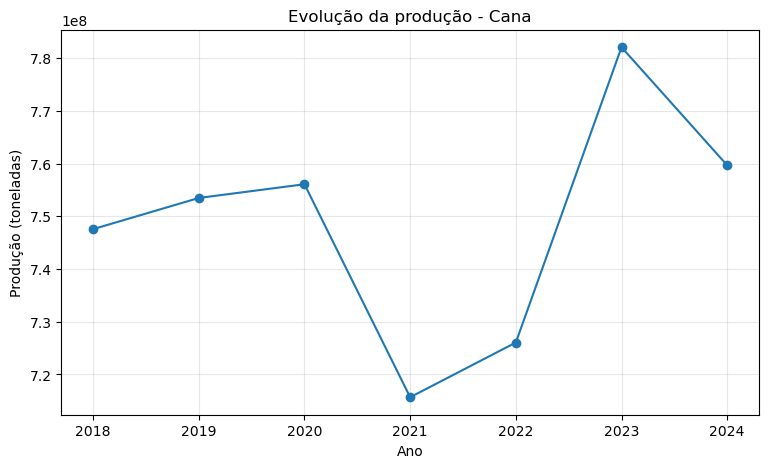

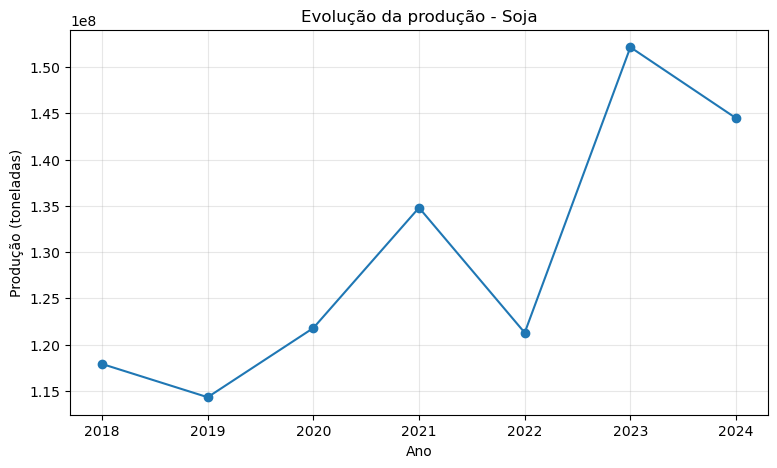

In [63]:
import matplotlib.pyplot as plt

for cultura in producao_anual["cultura"].unique():
    dados = producao_anual[
        producao_anual["cultura"] == cultura
    ]

    plt.figure(figsize=(9, 5))

    plt.plot(
        dados["ano"],
        dados["quantidade_produzida_t"],
        marker="o"
    )

    plt.title(
        f"Evolução da produção - {cultura.capitalize()}"
    )

    plt.xlabel("Ano")
    plt.ylabel("Produção (toneladas)")
    plt.grid(alpha=0.3)

    plt.show()

In [64]:
producao_uf = (
    pam_processado
    .groupby(
        ["uf", "cultura"],
        as_index=False
    )
    ["quantidade_produzida_t"]
    .sum()
)

producao_uf.head()

,uf,cultura,quantidade_produzida_t
0,AC,cana,81920.0
1,AC,soja,165950.0
2,AL,cana,122895177.0
3,AL,soja,74056.0
4,AM,cana,2109283.0


In [65]:
(
    producao_uf[
        producao_uf["cultura"] == "soja"
    ]
    .sort_values(
        "quantidade_produzida_t",
        ascending=False
    )
    .head(10)
)

,uf,cultura,quantidade_produzida_t
25,MT,soja,255105628.0
35,PR,soja,129163069.0
45,RS,soja,108052140.0
17,GO,soja,98662100.0
23,MS,soja,75768574.0
21,MG,soja,47670215.0
9,BA,soja,46961091.0
50,SP,soja,28004923.0
52,TO,soja,24172007.0
19,MA,soja,23331253.0


In [66]:
(
    producao_uf[
        producao_uf["cultura"] == "cana"
    ]
    .sort_values(
        "quantidade_produzida_t",
        ascending=False
    )
    .head(10)
)

,uf,cultura,quantidade_produzida_t
49,SP,cana,2.971069e+09
16,GO,cana,5.350545e+08
20,MG,cana,5.316960e+08
22,MS,cana,3.422724e+08
34,PR,cana,2.671739e+08
24,MT,cana,1.400269e+08
2,AL,cana,1.228952e+08
30,PE,cana,1.057030e+08
28,PB,cana,4.219295e+07
8,BA,cana,3.724581e+07


In [67]:
(
    pam_processado[
        pam_processado["cultura"] == "soja"
    ]
    .groupby(
        ["codigo_ibge", "municipio", "uf"],
        as_index=False
    )
    ["quantidade_produzida_t"]
    .sum()
    .sort_values(
        "quantidade_produzida_t",
        ascending=False
    )
    .head(20)
)

,codigo_ibge,municipio,uf,quantidade_produzida_t
2470,5107925,Sorriso,MT,15115545.0
388,2911105,Formosa do Rio Preto,BA,11991268.0
401,2928901,São Desidério,BA,11889523.0
2674,5218805,Rio Verde,GO,10112000.0
2425,5106240,Nova Ubiratã,MT,9612752.0
2370,5102637,Campo Novo do Parecis,MT,9390305.0
2423,5106224,Nova Mutum,MT,9375362.0
2467,5107875,Sapezal,MT,8860577.0
2388,5103502,Diamantino,MT,8704183.0
2446,5107065,Querência,MT,8603904.0


In [68]:
(
    pam_processado[
        pam_processado["cultura"] == "cana"
    ]
    .groupby(
        ["codigo_ibge", "municipio", "uf"],
        as_index=False
    )
    ["quantidade_produzida_t"]
    .sum()
    .sort_values(
        "quantidade_produzida_t",
        ascending=False
    )
    .head(20)
)

,codigo_ibge,municipio,uf,quantidade_produzida_t
1775,3170107,Uberaba,MG,59127820.0
2195,3531902,Morro Agudo,SP,48706710.0
3505,5218508,Quirinópolis,GO,44284701.0
3299,5006002,Nova Alvorada do Sul,MS,44183968.0
3307,5007208,Rio Brilhante,MS,44010351.0
1957,3505500,Barretos,SP,43070917.0
2067,3517406,Guaíra,SP,36892000.0
2130,3524303,Jaboticabal,SP,34918850.0
3475,5213103,Mineiros,GO,32830500.0
1302,3127107,Frutal,MG,32126560.0


In [69]:
mapa_regioes = {
    "AC": "Norte",
    "AP": "Norte",
    "AM": "Norte",
    "PA": "Norte",
    "RO": "Norte",
    "RR": "Norte",
    "TO": "Norte",

    "AL": "Nordeste",
    "BA": "Nordeste",
    "CE": "Nordeste",
    "MA": "Nordeste",
    "PB": "Nordeste",
    "PE": "Nordeste",
    "PI": "Nordeste",
    "RN": "Nordeste",
    "SE": "Nordeste",

    "DF": "Centro-Oeste",
    "GO": "Centro-Oeste",
    "MT": "Centro-Oeste",
    "MS": "Centro-Oeste",

    "ES": "Sudeste",
    "MG": "Sudeste",
    "RJ": "Sudeste",
    "SP": "Sudeste",

    "PR": "Sul",
    "RS": "Sul",
    "SC": "Sul"
}

pam_processado["regiao"] = (
    pam_processado["uf"]
    .map(mapa_regioes)
)

In [70]:
pam_processado[
    ["uf", "regiao"]
].drop_duplicates().sort_values(
    ["regiao", "uf"]
)

,uf,regiao
40016,DF,Centro-Oeste
37758,GO,Centro-Oeste
35509,MS,Centro-Oeste
36426,MT,Centro-Oeste
6527,AL,Nordeste
7173,BA,Nordeste
4208,CE,Nordeste
2573,MA,Nordeste
5354,PB,Nordeste
5939,PE,Nordeste


In [71]:
pam_processado["regiao"].isna().sum()

np.int64(0)

In [72]:
producao_regiao = (
    pam_processado
    .groupby(
        ["regiao", "ano", "cultura"],
        as_index=False
    )
    ["quantidade_produzida_t"]
    .sum()
)

producao_regiao.head(20)

,regiao,ano,cultura,quantidade_produzida_t
0,Centro-Oeste,2018,cana,145979551.0
1,Centro-Oeste,2018,soja,53208000.0
2,Centro-Oeste,2019,cana,150897007.0
3,Centro-Oeste,2019,soja,52281916.0
4,Centro-Oeste,2020,cana,144593999.0
5,Centro-Oeste,2020,soja,59149426.0
6,Centro-Oeste,2021,cana,138665786.0
7,Centro-Oeste,2021,soja,61535453.0
8,Centro-Oeste,2022,cana,131656283.0
9,Centro-Oeste,2022,soja,62083262.0


In [73]:
duplicados_final = (
    pam_processado
    .duplicated(
        subset=[
            "codigo_ibge",
            "ano",
            "cultura"
        ]
    )
    .sum()
)

print(
    "Duplicados na chave município-ano-cultura:",
    duplicados_final
)

Duplicados na chave município-ano-cultura: 0


In [74]:
pam_processado.isna().sum().sort_values(
    ascending=False
)

valor_producao_mil_reais    32
area_colhida_ha             17
quantidade_produzida_t      17
rendimento_medio_kg_ha      17
aproveitamento_area_pct     17
area_nao_colhida_ha         17
codigo_ibge                  0
municipio                    0
uf                           0
ano                          0
cultura                      0
area_plantada_ha             0
regiao                       0
dtype: int64

In [75]:
pam_processado = pam_processado[
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "regiao",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "area_nao_colhida_ha",
        "aproveitamento_area_pct",
        "quantidade_produzida_t",
        "rendimento_medio_kg_ha",
        "valor_producao_mil_reais"
    ]
].copy()

In [76]:
pam_processado.head()

,codigo_ibge,municipio,uf,regiao,ano,cultura,area_plantada_ha,area_colhida_ha,area_nao_colhida_ha,aproveitamento_area_pct,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
0,1100015,Alta Floresta D'Oeste,RO,Norte,2018,soja,450.0,450.0,0.0,100.0,1350.0,3000.0,1215.0
1,1100015,Alta Floresta D'Oeste,RO,Norte,2019,soja,450.0,450.0,0.0,100.0,1350.0,3000.0,1364.0
2,1100015,Alta Floresta D'Oeste,RO,Norte,2020,cana,10.0,10.0,0.0,100.0,300.0,30000.0,51.0
3,1100015,Alta Floresta D'Oeste,RO,Norte,2020,soja,450.0,450.0,0.0,100.0,1350.0,3000.0,2205.0
4,1100015,Alta Floresta D'Oeste,RO,Norte,2021,cana,10.0,10.0,0.0,100.0,300.0,30000.0,98.0


In [77]:
print("Linhas:", len(pam_processado))

print(
    "Municípios:",
    pam_processado["codigo_ibge"].nunique()
)

print(
    "Anos:",
    sorted(pam_processado["ano"].unique())
)

print(
    "Culturas:",
    pam_processado["cultura"].unique()
)

print(
    "Regiões:",
    pam_processado["regiao"].unique()
)

Linhas: 40030
Municípios: 4255
Anos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Culturas: <StringArray>
['soja', 'cana']
Length: 2, dtype: string
Regiões: ['Norte' 'Nordeste' 'Sudeste' 'Sul' 'Centro-Oeste']


In [81]:
from pathlib import Path

# Pasta onde o Jupyter está executando
CURRENT_DIR = Path.cwd()

print("Diretório atual:")
print(CURRENT_DIR)

Diretório atual:
C:\Users\Elaine Cristina\Downloads\agroesg-analytics\notebooks


In [82]:
BASE_DIR = CURRENT_DIR.parent

print("Raiz do projeto:")
print(BASE_DIR)

Raiz do projeto:
C:\Users\Elaine Cristina\Downloads\agroesg-analytics


In [83]:
PROCESSED_DIR = (
    BASE_DIR
    / "data"
    / "processed"
    / "ibge_pam"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Pasta de saída:")
print(PROCESSED_DIR)

Pasta de saída:
C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\processed\ibge_pam


In [84]:
arquivo_saida = (
    PROCESSED_DIR
    / "pam_soja_cana_municipios_2018_2024.csv"
)

pam_processado.to_csv(
    arquivo_saida,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Arquivo salvo em:",
    arquivo_saida
)

Arquivo salvo em: C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\processed\ibge_pam\pam_soja_cana_municipios_2018_2024.csv


In [85]:
teste_saida = pd.read_csv(
    arquivo_saida,
    dtype={
        "codigo_ibge": "string"
    }
)

teste_saida.head()

,codigo_ibge,municipio,uf,regiao,ano,cultura,area_plantada_ha,area_colhida_ha,area_nao_colhida_ha,aproveitamento_area_pct,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
0,1100015,Alta Floresta D'Oeste,RO,Norte,2018,soja,450.0,450.0,0.0,100.0,1350.0,3000.0,1215.0
1,1100015,Alta Floresta D'Oeste,RO,Norte,2019,soja,450.0,450.0,0.0,100.0,1350.0,3000.0,1364.0
2,1100015,Alta Floresta D'Oeste,RO,Norte,2020,cana,10.0,10.0,0.0,100.0,300.0,30000.0,51.0
3,1100015,Alta Floresta D'Oeste,RO,Norte,2020,soja,450.0,450.0,0.0,100.0,1350.0,3000.0,2205.0
4,1100015,Alta Floresta D'Oeste,RO,Norte,2021,cana,10.0,10.0,0.0,100.0,300.0,30000.0,98.0


In [86]:
print(
    "Dimensão original:",
    pam_processado.shape
)

print(
    "Dimensão arquivo salvo:",
    teste_saida.shape
)

Dimensão original: (40030, 13)
Dimensão arquivo salvo: (40030, 13)


In [87]:
assert pam_processado["codigo_ibge"].notna().all()

assert pam_processado["municipio"].notna().all()

assert pam_processado["uf"].notna().all()

assert pam_processado["regiao"].notna().all()

assert pam_processado["ano"].between(
    2018,
    2024
).all()

assert set(
    pam_processado["cultura"].unique()
) <= {"soja", "cana"}

assert (
    pam_processado[
        [
            "area_plantada_ha",
            "area_colhida_ha",
            "quantidade_produzida_t",
            "rendimento_medio_kg_ha",
            "valor_producao_mil_reais"
        ]
    ] < 0
).sum().sum() == 0

assert (
    pam_processado
    .duplicated(
        subset=[
            "codigo_ibge",
            "ano",
            "cultura"
        ]
    )
    .sum()
    == 0
)

print("✅ Validação final concluída.")

✅ Validação final concluída.


# 9. Construção da camada Curated

A camada `Processed` contém os dados da Pesquisa Agrícola Municipal (PAM)
após limpeza, padronização, tipagem e validações de qualidade.

Nesta etapa é construída a camada `Curated`, destinada às regras de negócio
e aos recortes analíticos definidos para o projeto AgroESG.

Regras aplicadas:

- período analítico: 2019 a 2024;
- culturas de interesse: soja e cana-de-açúcar;
- classificação dos municípios pelas cinco macrorregiões brasileiras;
- criação de indicadores derivados de utilização da área agrícola.

A camada `Processed` é preservada sem alterações.

In [88]:
pam_curated = pam_processado.copy()

print("Dimensão da camada Processed:", pam_processado.shape)
print("Dimensão inicial da camada Curated:", pam_curated.shape)

Dimensão da camada Processed: (40030, 13)
Dimensão inicial da camada Curated: (40030, 13)


In [89]:
pam_curated = (
    pam_curated[
        pam_curated["ano"].between(2019, 2024)
    ]
    .copy()
)

print(
    "Anos da camada Curated:",
    sorted(pam_curated["ano"].unique())
)

Anos da camada Curated: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [90]:
culturas_projeto = [
    "soja",
    "cana"
]

pam_curated = (
    pam_curated[
        pam_curated["cultura"].isin(culturas_projeto)
    ]
    .copy()
)

print(
    "Culturas:",
    pam_curated["cultura"].unique()
)

Culturas: <StringArray>
['soja', 'cana']
Length: 2, dtype: string


In [91]:
mapa_regioes = {
    "AC": "Norte",
    "AP": "Norte",
    "AM": "Norte",
    "PA": "Norte",
    "RO": "Norte",
    "RR": "Norte",
    "TO": "Norte",

    "AL": "Nordeste",
    "BA": "Nordeste",
    "CE": "Nordeste",
    "MA": "Nordeste",
    "PB": "Nordeste",
    "PE": "Nordeste",
    "PI": "Nordeste",
    "RN": "Nordeste",
    "SE": "Nordeste",

    "ES": "Sudeste",
    "MG": "Sudeste",
    "RJ": "Sudeste",
    "SP": "Sudeste",

    "PR": "Sul",
    "RS": "Sul",
    "SC": "Sul",

    "DF": "Centro-Oeste",
    "GO": "Centro-Oeste",
    "MT": "Centro-Oeste",
    "MS": "Centro-Oeste"
}

pam_curated["regiao"] = (
    pam_curated["uf"]
    .map(mapa_regioes)
)

In [92]:
print(
    pam_curated["regiao"]
    .value_counts(dropna=False)
)

print(
    "\nRegiões:",
    pam_curated["regiao"].unique()
)

regiao
Sudeste         12109
Sul             10873
Nordeste         5267
Centro-Oeste     3867
Norte            2248
Name: count, dtype: int64

Regiões: ['Norte' 'Nordeste' 'Sudeste' 'Sul' 'Centro-Oeste']


In [93]:
pam_curated["area_nao_colhida_ha"] = (
    pam_curated["area_plantada_ha"]
    - pam_curated["area_colhida_ha"]
)

In [94]:
import numpy as np

pam_curated["aproveitamento_area_pct"] = np.where(
    pam_curated["area_plantada_ha"] > 0,
    (
        pam_curated["area_colhida_ha"]
        / pam_curated["area_plantada_ha"]
        * 100
    ),
    np.nan
)

In [95]:
pam_curated[
    [
        "codigo_ibge",
        "municipio",
        "uf",
        "regiao",
        "ano",
        "cultura",
        "area_plantada_ha",
        "area_colhida_ha",
        "area_nao_colhida_ha",
        "aproveitamento_area_pct",
        "quantidade_produzida_t",
        "rendimento_medio_kg_ha",
        "valor_producao_mil_reais"
    ]
].head(10)

,codigo_ibge,municipio,uf,regiao,ano,cultura,area_plantada_ha,area_colhida_ha,area_nao_colhida_ha,aproveitamento_area_pct,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
1,1100015,Alta Floresta D'Oeste,RO,Norte,2019,soja,450.0,450.0,0.0,100.0,1350.0,3000.0,1364.0
2,1100015,Alta Floresta D'Oeste,RO,Norte,2020,cana,10.0,10.0,0.0,100.0,300.0,30000.0,51.0
3,1100015,Alta Floresta D'Oeste,RO,Norte,2020,soja,450.0,450.0,0.0,100.0,1350.0,3000.0,2205.0
4,1100015,Alta Floresta D'Oeste,RO,Norte,2021,cana,10.0,10.0,0.0,100.0,300.0,30000.0,98.0
5,1100015,Alta Floresta D'Oeste,RO,Norte,2021,soja,1072.0,1072.0,0.0,100.0,2500.0,2332.0,5945.0
6,1100015,Alta Floresta D'Oeste,RO,Norte,2022,soja,1117.0,1117.0,0.0,100.0,4915.0,4400.0,14090.0
7,1100015,Alta Floresta D'Oeste,RO,Norte,2023,cana,5.0,5.0,0.0,100.0,143.0,28600.0,112.0
8,1100015,Alta Floresta D'Oeste,RO,Norte,2023,soja,1318.0,1318.0,0.0,100.0,4824.0,3660.0,10968.0
9,1100015,Alta Floresta D'Oeste,RO,Norte,2024,cana,5.0,5.0,0.0,100.0,143.0,28600.0,79.0
10,1100015,Alta Floresta D'Oeste,RO,Norte,2024,soja,1697.0,1697.0,0.0,100.0,6211.0,3660.0,10061.0


In [96]:
colunas_curated = [
    "codigo_ibge",
    "municipio",
    "uf",
    "regiao",
    "ano",
    "cultura",
    "area_plantada_ha",
    "area_colhida_ha",
    "area_nao_colhida_ha",
    "aproveitamento_area_pct",
    "quantidade_produzida_t",
    "rendimento_medio_kg_ha",
    "valor_producao_mil_reais"
]

pam_curated = (
    pam_curated[colunas_curated]
    .sort_values(
        [
            "codigo_ibge",
            "ano",
            "cultura"
        ]
    )
    .reset_index(drop=True)
)

pam_curated.head()

,codigo_ibge,municipio,uf,regiao,ano,cultura,area_plantada_ha,area_colhida_ha,area_nao_colhida_ha,aproveitamento_area_pct,quantidade_produzida_t,rendimento_medio_kg_ha,valor_producao_mil_reais
0,1100015,Alta Floresta D'Oeste,RO,Norte,2019,soja,450.0,450.0,0.0,100.0,1350.0,3000.0,1364.0
1,1100015,Alta Floresta D'Oeste,RO,Norte,2020,cana,10.0,10.0,0.0,100.0,300.0,30000.0,51.0
2,1100015,Alta Floresta D'Oeste,RO,Norte,2020,soja,450.0,450.0,0.0,100.0,1350.0,3000.0,2205.0
3,1100015,Alta Floresta D'Oeste,RO,Norte,2021,cana,10.0,10.0,0.0,100.0,300.0,30000.0,98.0
4,1100015,Alta Floresta D'Oeste,RO,Norte,2021,soja,1072.0,1072.0,0.0,100.0,2500.0,2332.0,5945.0


## 10. Validação da camada Curated

Antes da exportação são verificadas as regras de negócio aplicadas,
a unicidade da chave município-ano-cultura, o período temporal,
as culturas selecionadas e a classificação regional.

In [97]:
print("Dimensão:", pam_curated.shape)

print(
    "Municípios:",
    pam_curated["codigo_ibge"].nunique()
)

print(
    "Anos:",
    sorted(pam_curated["ano"].unique())
)

print(
    "Culturas:",
    pam_curated["cultura"].unique()
)

print(
    "Regiões:",
    pam_curated["regiao"].unique()
)

Dimensão: (34364, 13)
Municípios: 4233
Anos: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Culturas: <StringArray>
['soja', 'cana']
Length: 2, dtype: string
Regiões: ['Norte' 'Nordeste' 'Sudeste' 'Sul' 'Centro-Oeste']


In [98]:
duplicados_curated = (
    pam_curated
    .duplicated(
        subset=[
            "codigo_ibge",
            "ano",
            "cultura"
        ]
    )
    .sum()
)

print(
    "Duplicados na chave município-ano-cultura:",
    duplicados_curated
)

Duplicados na chave município-ano-cultura: 0


In [99]:
regioes_ausentes = (
    pam_curated["regiao"]
    .isna()
    .sum()
)

print(
    "Regiões ausentes:",
    regioes_ausentes
)

Regiões ausentes: 0


# 11. Exportação das camadas de dados

São gerados dois datasets distintos:

- `Processed`: dados higienizados e normalizados, preservando o período disponível na fonte;
- `Curated`: dados preparados para o escopo analítico do AgroESG.

In [101]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

print("Raiz do projeto:")
print(BASE_DIR)

Raiz do projeto:
C:\Users\Elaine Cristina\Downloads\agroesg-analytics


In [102]:
PROCESSED_DIR = (
    BASE_DIR
    / "data"
    / "databases_processed"
    / "ibge_pam"
)

CURATED_DIR = (
    BASE_DIR
    / "data"
    / "databases_curated"
    / "ibge_pam"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CURATED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed:", PROCESSED_DIR)
print("Curated:", CURATED_DIR)

Processed: C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\databases_processed\ibge_pam
Curated: C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\databases_curated\ibge_pam


In [103]:
arquivo_processed = (
    PROCESSED_DIR
    / "pam_processed_2018_2024.csv"
)

pam_processado.to_csv(
    arquivo_processed,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Processed salvo em:",
    arquivo_processed
)

Processed salvo em: C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\databases_processed\ibge_pam\pam_processed_2018_2024.csv


In [104]:
arquivo_curated = (
    CURATED_DIR
    / "pam_curated_soja_cana_2019_2024.csv"
)

pam_curated.to_csv(
    arquivo_curated,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Curated salvo em:",
    arquivo_curated
)

Curated salvo em: C:\Users\Elaine Cristina\Downloads\agroesg-analytics\data\databases_curated\ibge_pam\pam_curated_soja_cana_2019_2024.csv


In [105]:
print(
    "Processed existe?",
    arquivo_processed.exists()
)

print(
    "Curated existe?",
    arquivo_curated.exists()
)

Processed existe? True
Curated existe? True


In [106]:
teste_processed = pd.read_csv(
    arquivo_processed,
    dtype={
        "codigo_ibge": "string"
    }
)

teste_curated = pd.read_csv(
    arquivo_curated,
    dtype={
        "codigo_ibge": "string"
    }
)

print(
    "Processed:",
    teste_processed.shape
)

print(
    "Curated:",
    teste_curated.shape
)

Processed: (40030, 13)
Curated: (34364, 13)


In [107]:
assert teste_processed["ano"].min() == 2018
assert teste_processed["ano"].max() == 2024

assert teste_curated["ano"].min() == 2019
assert teste_curated["ano"].max() == 2024

assert set(
    teste_curated["cultura"].unique()
) == {"soja", "cana"}

assert (
    teste_curated["regiao"]
    .isna()
    .sum()
) == 0

print(
    "✅ Camadas Processed e Curated exportadas e validadas com sucesso."
)

✅ Camadas Processed e Curated exportadas e validadas com sucesso.


# Conclusão

A base da Pesquisa Agrícola Municipal (PAM/IBGE — Tabela 1612)
foi submetida a um pipeline estruturado de tratamento de dados.

A camada `RAW` preserva o arquivo original disponibilizado pelo IBGE.

A camada `Processed` contém os dados após interpretação da estrutura
do arquivo, padronização, tipagem, tratamento de valores ausentes,
validação de duplicidades e verificações de consistência.

A camada `Curated` aplica as regras analíticas do projeto AgroESG,
considerando o período de 2019 a 2024, as culturas de soja e
cana-de-açúcar e a classificação dos municípios pelas cinco
macrorregiões brasileiras.

Também foram derivados indicadores de utilização da área agrícola,
mantendo a rastreabilidade entre os dados originais, os dados
processados e a camada preparada para análises posteriores.

A base Curated está preparada para integração com as demais fontes
ambientais e climáticas do projeto, utilizando principalmente
`codigo_ibge` e `ano` como chaves de integração.